In [21]:
import jax 
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jr
from functools import partial

In [17]:
def gen_brow_path(key, T, N, M):
    
    dt = T / N
    dW = jr.normal(key, (M,N)) * jnp.sqrt(dt)
    
    W = jnp.cumsum(dW, axis=1)
    
    W = jnp.pad(W, ((0,0), (1,0)), constant_values=0)
    
    return W

def europ_call_payoff(S0, r, sigma, W, T, K):
    ST = S0 * jnp.exp( (r - 0.5 * sigma**2) * T + sigma * W[:, -1])
    #payoff is max(ST - K, 0)
    return jnp.maximum(ST - K, 0)

key = jr.PRNGKey(0)
M, N, T = 10000, 252, 1.0  # 10k paths, 252 trading days, 1 year
W = gen_brow_path(key, T, N, M)
S0, r, sigma, K = 100.0, 0.05, 0.2, 100.0

# Calculate option price (discounted expected payoff)
payoffs = europ_call_payoff(S0, r, sigma, W, T, K)
option_price = jnp.exp(-r * T) * jnp.mean(payoffs)

option_price

Array(10.477898, dtype=float32)

In [18]:
def gen_anti_brow_path(key, T, N, M):
    w_posi = gen_brow_path(key, T, N, M//2)
    
    W_neg = -w_posi
    
    return jnp.vstack([w_posi, W_neg])

def europ_call_with_control_val(S0, r, sigma, W, T, K):
    ST = S0 * jnp.exp((r - 0.5 * sigma**2) * T + sigma * W[:, -1])
    payoffs = jnp.maximum(ST - K, 0)
    
    d1 = (jnp.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*jnp.sqrt(T))
    d2 = d1 - sigma*jnp.sqrt(T)
    bs_price = S0* jsp.stats.norm.cdf(d1) - K*jnp.exp(-r*T)* jsp.stats.norm.cdf(d2)
    
    # Adjust payoffs using control variate
    # Note: In practice, you'd estimate the optimal beta coefficient
    beta = 0.75  # Example value, should be optimized
    adjusted_payoffs = payoffs - beta * (ST - S0*jnp.exp(r*T))
    
    return adjusted_payoffs, bs_price


def euler_maruyama(key, drift, diffusion, x0, T, N, M):
    """Solve dX = μ(X,t)dt + σ(X,t)dW using Euler-Maruyama"""
    dt = T / N
    t = jnp.linspace(0, T, N+1)
    
    # Initialize paths
    X = jnp.ones((M, N+1)) * x0
    
    # Generate Brownian increments
    dW = jax.random.normal(key, (M, N)) * jnp.sqrt(dt)
    
    # Time stepping
    def step(carry, i):
        X_prev, dW_slice = carry
        t_prev = t[i]
        X_next = X_prev + drift(X_prev, t_prev) * dt + diffusion(X_prev, t_prev) * dW_slice[i]
        return (X_next, dW_slice), X_next
    
    _, X_all = jax.lax.scan(step, (X[:, 0], dW), jnp.arange(1, N+1))
    
    # Transpose to get shape (M, N+1)
    return jnp.vstack([X[:, 0], X_all.T])

In [22]:
#@jax.jit
@partial(jax.jit, static_argnums=(6,7))
def monte_carlo_option_price(key, S0, r, sigma, T, K, M, N):
    W = gen_brow_path(key, T, N, M)
    ST = S0 * jnp.exp((r - 0.5 * sigma**2) * T + sigma * W[:, -1])
    payoffs = jnp.maximum(ST - K, 0)
    return jnp.exp(-r * T) * jnp.mean(payoffs)

# Split keys for different parts of your simulation
key, subkey1, subkey2 = jax.random.split(key, 3)
W1 = gen_brow_path(subkey1, T, N, M//2)
W2 = gen_brow_path(subkey2, T, N, M//2)

#delta = jax.grad(lambda s0: monte_carlo_option_price(key, s0, r, sigma, T, K, M, N))(S0)
delta = jax.grad(monte_carlo_option_price, argnums=1)(key, S0, r, sigma, T, K, M, N)

def generate_correlated_brownian_paths(key, T, N, M, rho):
    """
    Generate 2 correlated Brownian motions with correlation rho
    
    Parameters:
    - rho: Correlation coefficient between -1 and 1
    
    Returns:
    - Array of shape (M, 2, N+1) containing two correlated Brownian paths
    """
    # Generate independent Brownian motions
    dW = jax.random.normal(key, (M, 2, N)) * jnp.sqrt(T/N)
    
    # Apply Cholesky decomposition for correlation
    L = jnp.array([[1.0, 0.0], [rho, jnp.sqrt(1 - rho**2)]])
    dW_corr = jnp.einsum('ij,mjk->mik', L, dW)
    
    # Cumulative sum to get paths
    W = jnp.cumsum(dW_corr, axis=2)
    W = jnp.pad(W, ((0, 0), (0, 0), (1, 0)), constant_values=0)
    return W

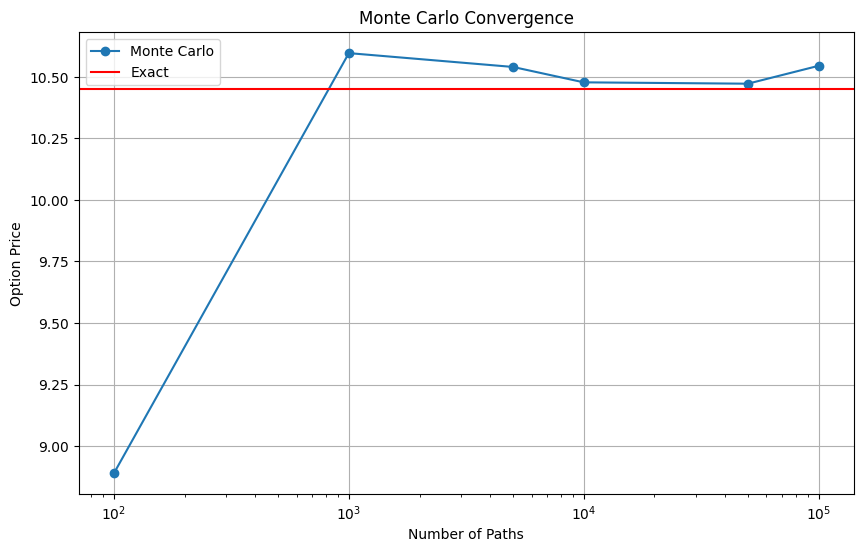

In [24]:
def test_convergence():
    exact_price = 10.45058  # Example Black-Scholes price
    
    path_counts = [100, 1000, 5000, 10000, 50000, 100000]
    prices = []
    
    for M in path_counts:
        key = jax.random.PRNGKey(0)
        price = monte_carlo_option_price(key, S0, r, sigma, T, K, M, 252)
        prices.append(price)
    
    # Plot convergence
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(path_counts, prices, 'o-', label='Monte Carlo')
    plt.axhline(y=exact_price, color='r', linestyle='-', label='Exact')
    plt.xscale('log')
    plt.xlabel('Number of Paths')
    plt.ylabel('Option Price')
    plt.title('Monte Carlo Convergence')
    plt.legend()
    plt.grid(True)
    plt.show()
    
test_convergence()